In [366]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib.colors as mcolors

In [367]:
xplot = np.linspace(0, 28, 560)
yplot = np.linspace(0, 20, 400)

X, Y = np.meshgrid(xplot, yplot, indexing='xy')

In [368]:
def dist(x,y,u,v):
    return np.sqrt((x-u)**2+(y-v)**2)

def func(x):
    return np.pow(x,1)

def potencial(X,Y):
    diferenciaPotencial = 19
    radioEsferico = 0.5

    offsetPotencial = diferenciaPotencial/2

    distanceUno = dist(X, Y, 7, 10)
    distanceDos = dist(X, Y, 21, 10)

    constantePotencial = func(radioEsferico)*diferenciaPotencial/2

    return np.where(distanceUno < radioEsferico,
                    -diferenciaPotencial/2,
                    np.where(distanceDos < radioEsferico,
                             diferenciaPotencial/2,
                             -constantePotencial/func(distanceUno) + constantePotencial/func(distanceDos)
                             )
                    ) + offsetPotencial

    '''if (dist(x,y,7,10) < 0.1):
        return 0
    else:
        if (dist(x,y,21,10) < 0.1):
            return 19
        else:
            return -10/(dist(x,y,7,10)+0.5) + 10/(dist(x,y,21,10)+0.5)'''

def potencialprimo(X,Y):
    K = 3.5

    offsetPotencial = 18.76/2

    distanceUno = dist(X, Y, 7, 10)
    distanceDos = dist(X, Y, 21, 10)

    return K*np.log(distanceUno/distanceDos) + offsetPotencial


In [369]:
data = potencialprimo(X,Y)

In [370]:
realSpacingInXplotSpace = 29/xplot.size
realSpacingInYplotSpace = 21/yplot.size

fieldGradient = -np.array(np.gradient(data, realSpacingInYplotSpace, realSpacingInXplotSpace)) #unidades de voltio / cm

In [371]:
normMatrix = np.sqrt(fieldGradient[0]**2 + fieldGradient[1]**2)
normalizedFieldGradientU = fieldGradient[0]/normMatrix
normalizedFieldGradientV = fieldGradient[1]/normMatrix

In [372]:
colors = ["#03071e","#370617","#6a040f","#9d0208","#d00000","#dc2f02","#e85d04","#f48c06","#faa307"]
red_orange_cmap = mpl.colors.LinearSegmentedColormap.from_list("red_orange", colors)

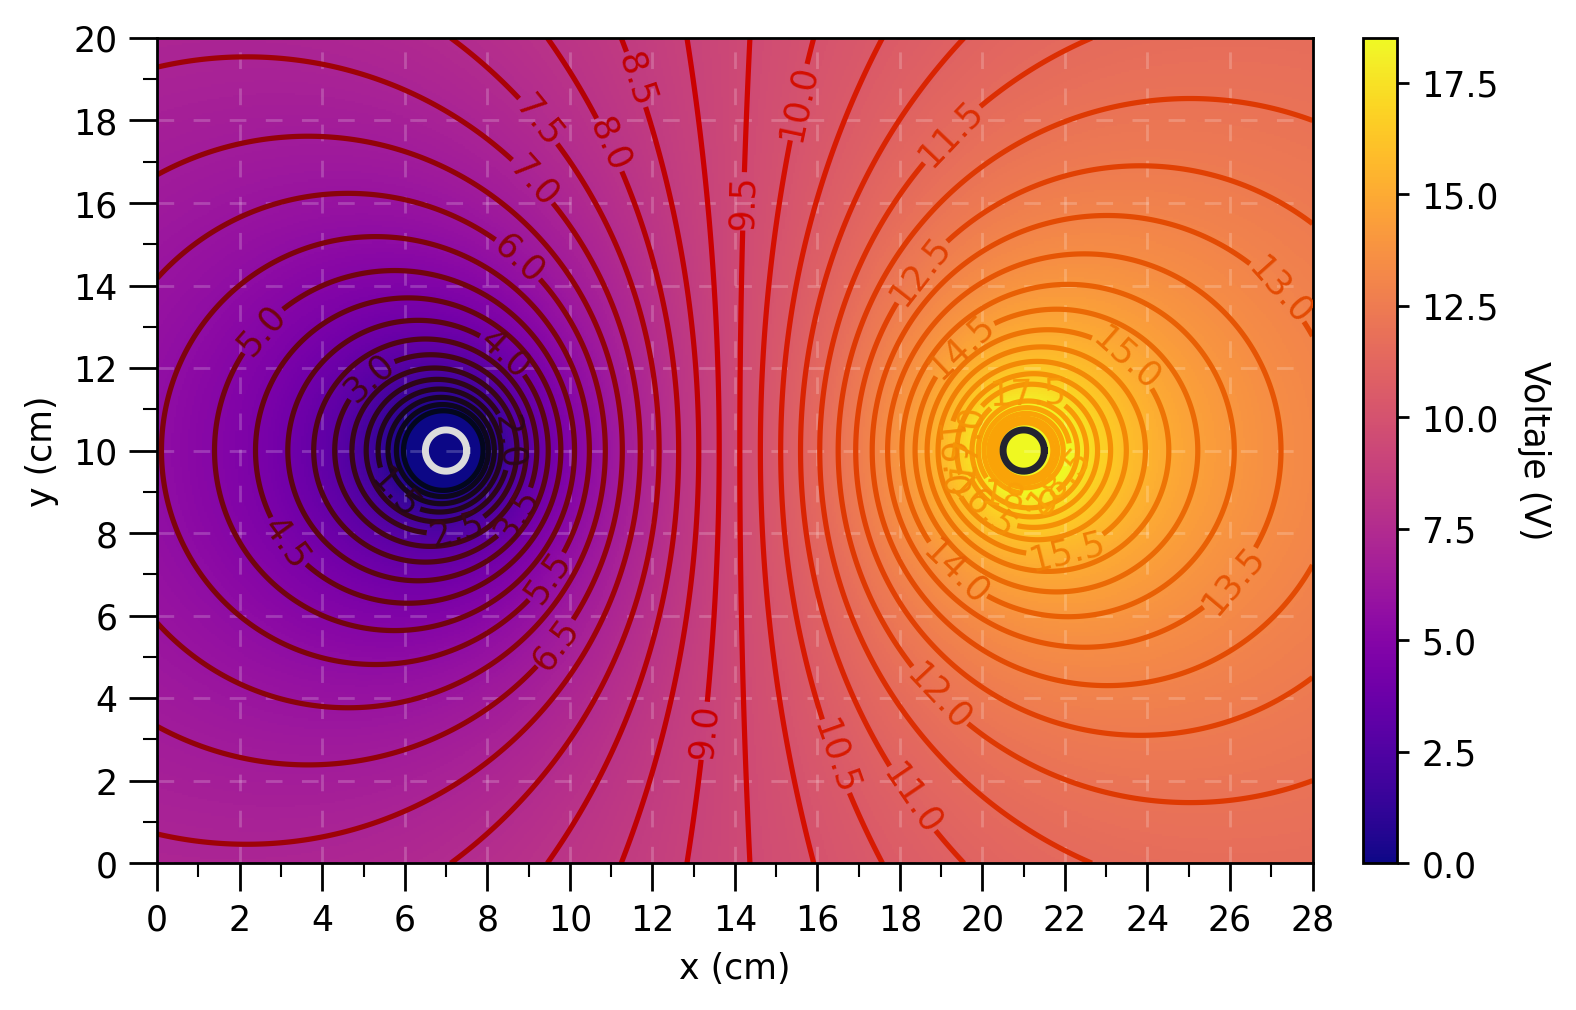

In [384]:
chargePositions = np.array([[7,10],[21,10]])
chargeColors = ["gainsboro","#232330"]

fig, ax = plt.subplots(dpi = 250)
divider = make_axes_locatable(ax)

norm = mcolors.Normalize(vmin = -0, vmax = 18.5)

levels = np.linspace(0,20,21)

img = ax.imshow(data, aspect='equal', cmap = "plasma", origin = "lower", interpolation = "nearest", extent = (0,28,0,20), norm = norm)
CS = ax.contour(X, Y, data, levels = levels, cmap = red_orange_cmap, zorder = 2, norm = norm)
ax.clabel(CS, levels[3:-3], fontsize = 10)

#ax.scatter(chargePositions[:,0], chargePositions[:,1], c = chargeColors, zorder = 15)

theta = np.linspace(0, 2*np.pi, 400)
plt.plot(7 + 0.5*np.cos(theta), 10 + 0.5*np.sin(theta), "gainsboro", linewidth=2)
plt.plot(21 + 0.5*np.cos(theta), 10 + 0.5*np.sin(theta), "#232330", linewidth=2)


cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = fig.colorbar(img, cax=cax, norm = norm)
cbar.set_label('Voltaje (V)',rotation=-90,  labelpad=15)


ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#FFFFFF", zorder = 1, alpha = 0.2, ls = (0,(6,7)))

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
'''
cax = divider.append_axes("right", size="3%", pad=0.0)
cbar = plt.colorbar(sc, cax=cax)
cbar.set_label('Voltaje (V)',rotation=-90,  labelpad=15)'''


plt.savefig("casoUnoEquipotencialesTeoricasDipolo.png", dpi = 250, bbox_inches='tight', pad_inches=0.03)
plt.show()

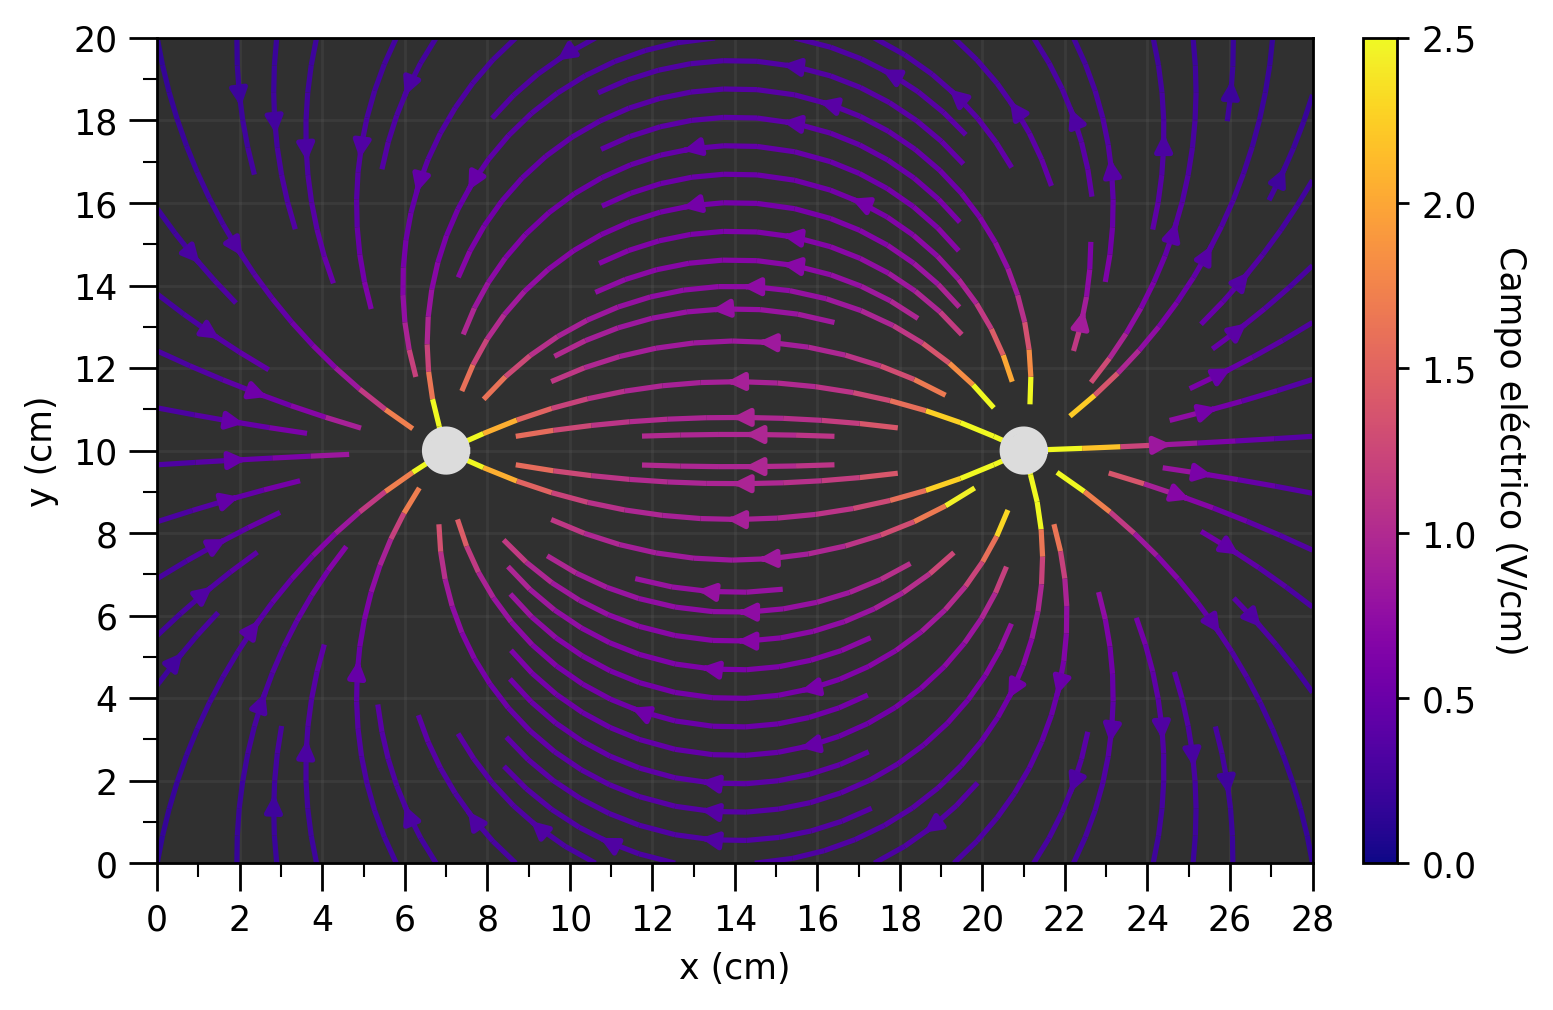

In [385]:
fig, ax = plt.subplots(dpi = 250)

divider = make_axes_locatable(ax)

norm = mcolors.Normalize(vmin=0, vmax=2.5)


isStreamlineBroken = True

normalizationFactor = np.max(fieldGradient[1]*fieldGradient[0])

stream = plt.streamplot(X,Y, fieldGradient[1], fieldGradient[0],
               color = np.sqrt(fieldGradient[1]**2+fieldGradient[0]**2),
               density = 1, cmap = "plasma",
               broken_streamlines = isStreamlineBroken,
                        norm = norm
               )
#ax.scatter(chargePositions[:,0], chargePositions[:,1], c = "gainsboro", zorder = 10)

theta = np.linspace(0, 2*np.pi, 400)
plt.plot(7 + 0.5*np.cos(theta), 10 + 0.5*np.sin(theta), "gainsboro", linewidth=2, zorder = 10)
plt.plot(21 + 0.5*np.cos(theta), 10 + 0.5*np.sin(theta), "gainsboro", linewidth=2, zorder = 10)

plt.scatter(chargePositions[:,0], chargePositions[:,1], s = 100, color = "gainsboro", zorder = 9)

cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = fig.colorbar(stream.lines, cax=cax, norm=norm)
cbar.set_label('Campo eléctrico (V/cm)',rotation=-90,  labelpad=15)

ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#666666", zorder = 10, alpha = 0.2, ls = "solid")

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

ax.set_aspect("equal")

ax.set_facecolor('#303030')


plt.savefig(f"casoUnoCampoElectricoTeoricoDipolo{isStreamlineBroken}.png", dpi = 250, bbox_inches='tight', pad_inches=0.03)
plt.show()

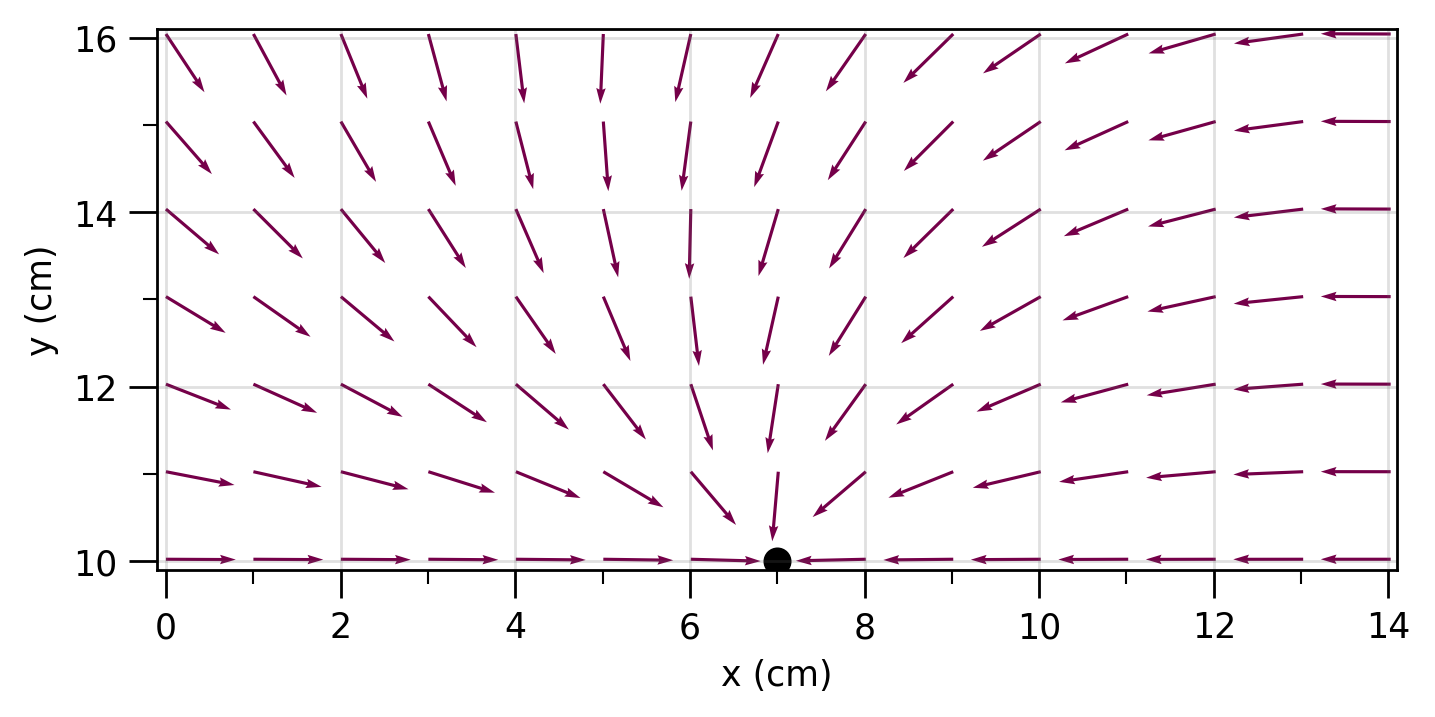

In [401]:
fig, ax = plt.subplots(dpi = 250)

skip = (slice(None, None, 20), slice(None, None, 20))
ax.quiver(X[skip],Y[skip], 0.8*normalizedFieldGradientV[skip], 0.8*normalizedFieldGradientU[skip], color = "#750049", angles='xy', scale_units='xy', scale = 1, cmap = 'rainbow')#, pivot = "mid")

ax.scatter(7,10, c = "black", s = 50)

ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#666666", zorder = 10, alpha = 0.2, ls = "solid")

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

ax.set_aspect("equal")

#ax.set_facecolor('#303030')

ax.set_xlim(0-0.1,14+0.1)
ax.set_ylim(10-0.1,16+0.1)

plt.savefig(f"casoUnoCampoElectricoTeoricoGridDipolo.png", dpi = 250, bbox_inches='tight', pad_inches=0.03)
plt.show()